In [1]:
import numpy as np
import numpy.random as rng
from resources.OTHERS.models import paraboloid_model, true_target_sampler_paraboloid
from resources.OTHERS.models import ridge_switch_model
from src.plot import plot_scatter_xi_list
import matplotlib.pyplot as plt

In [2]:
def theta_sampler(n, lb=-15, ub=15):
    return np.random.uniform(lb, ub, size=(n, 2))

def prior_sampler_xa(n, lb=-15, ub=15):
    return np.random.uniform(lb, ub, size=(n, 2))

def prep_sim_archive(N_SIM, xi_list):
    # ---- make xi_list a 2D array: (E, d_xi) ----
    xi_arr = np.asarray(xi_list, dtype=float)
    if xi_arr.ndim == 1:           # scalar or 1D -> (E=length, 1) OR (1, d_xi)
        # If it's a list of scalars, make it a column; if it's a single vector, keep it as one row
        if xi_arr.size == 1:
            xi_arr = xi_arr[None, :]            # (1, 1)
        else:
            # Heuristic: treat as a list of scalar designs
            xi_arr = xi_arr.reshape(-1, 1)      # (E, 1)
    E, d_xi = xi_arr.shape

    # ---- allocate counts per design (sum to N_SIM) ----
    base = N_SIM // E
    counts = np.full(E, base, dtype=int)
    counts[: (N_SIM - base * E)] += 1  # distribute remainder to first designs

    # ---- deterministically repeat each xi ----
    xi_sim_pool = np.repeat(xi_arr, counts, axis=0)   # (N_SIM, d_xi)

    # ---- your existing θ and y generation ----
    xe_sim_pool  = np.tile([2.5, 20.0], (xi_sim_pool.shape[0], 1))   # (N_SIM, 2)
    xa_sim_pool  = prior_sampler_xa(xi_sim_pool.shape[0])            # (N_SIM, d_xa)
    theta_sim_pool = np.hstack([xa_sim_pool, xe_sim_pool])           # (N_SIM, d_theta)

    # If model expects xi as a 1-D vector when d_xi==1, pass raveled xi
    xi_for_model = xi_sim_pool.ravel() if d_xi == 1 else xi_sim_pool
    y_sim_pool   = paraboloid_model(theta_sim_pool, xi_for_model)    # (N_SIM, d_y)

    return {"y": y_sim_pool, "theta": theta_sim_pool, "xi": xi_sim_pool}, \
           [y_sim_pool, theta_sim_pool, xi_sim_pool]


Designs #8; Samples #40


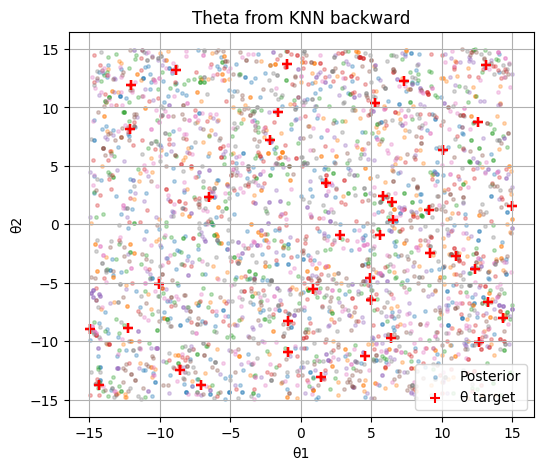

In [3]:
# generate data for the horse and pony show
N_emp = 40
theta_true_cloud = theta_sampler(N_emp)
xi_list = [-3.0, -1.0, 0.2, 2.0, 4.0, 23.0 , -2, 0.1]
observations = []
for xi in xi_list:
    y_emp  = paraboloid_model(theta_true_cloud, xi)  # shape (100,1) per design
    observations.append((y_emp, xi))
print(f"Designs #{len(observations)}; Samples #{observations[0][0].shape[0]}")

N_SIM, knn, resample_n, a_tol = 10_000, 10, 5_000, 0.05
_, simulated_data_list = prep_sim_archive(N_SIM, xi_list)
fig, ax = plt.subplots(figsize=(6, 5))
plot_scatter_xi_list(observations, simulated_data_list, a_tol, knn, theta_true_cloud, ax)
plt.show()


In [4]:
from src.backward import estimate_p_theta_knn_multi
observed_data_list = [o[0] for o in observations]
xi_star_list = [o[1] for o in observations]
res = estimate_p_theta_knn_multi(observed_data_list, simulated_data_list,  xi_star_list ,
                                 knn=100,  a_tol=0.05, return_full_cov=False, combine_results=True)

In [5]:
# Per experiment objects
per_exp = res["per_experiment"]        # list of length E
E = res["meta"]["n_experiments"]

# Example: experiment e
e = 0
theta_knn_e      = per_exp[e]["theta_samples"]         # (n_obs_e, K_e, d_theta)
indices_local_e  = per_exp[e]["knn_indices"]           # (n_obs_e, K_e), within filtered subset
indices_global_e = per_exp[e]["knn_indices_global"]    # (n_obs_e, K_e), into original archive
epsilon_e        = per_exp[e]["epsilon"]               # (n_obs_e,)
distances_e      = per_exp[e]["output_spread"]["distances"]  # (n_obs_e, K_e)
theta_mean_e     = per_exp[e]["input_spread"]["theta_mean"]  # (n_obs_e, d_theta)
theta_std_e      = per_exp[e]["input_spread"]["theta_std"]   # (n_obs_e, d_theta)
theta_radius     = per_exp[e]["input_spread"]["theta_radius"]  # (n_obs_e, d_theta)
theta_anisotropy      = per_exp[e]["input_spread"]["theta_anisotropy"]   # (n_obs_e, d_theta)

# Combined (stacked) convenience views
theta_knn_all = res["combined"]["theta_samples"]       # (sum n_obs_e, max_K, d_theta) with NaN-pad
epsilon_all   = res["combined"]["epsilon"]             # (sum n_obs_e,)
exp_id_all    = res["combined"]["experiment_index"]    # (sum n_obs_e,)

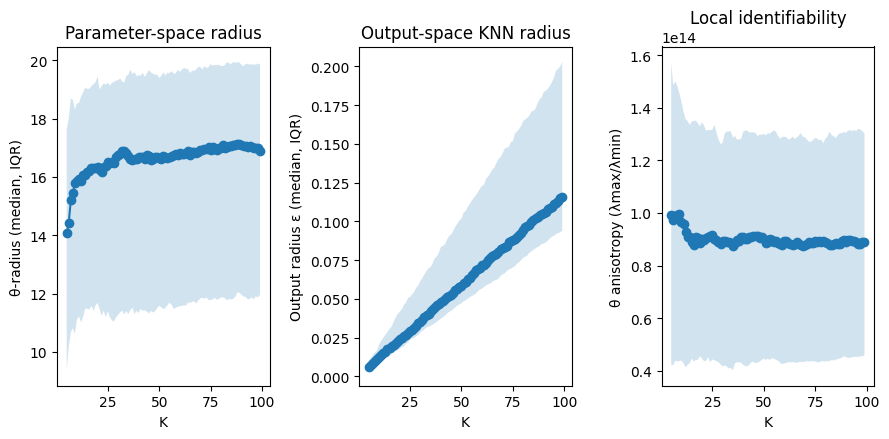

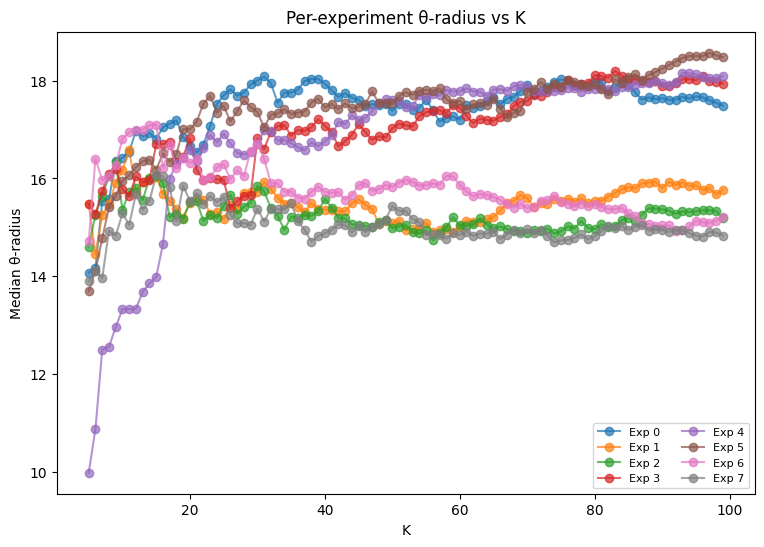

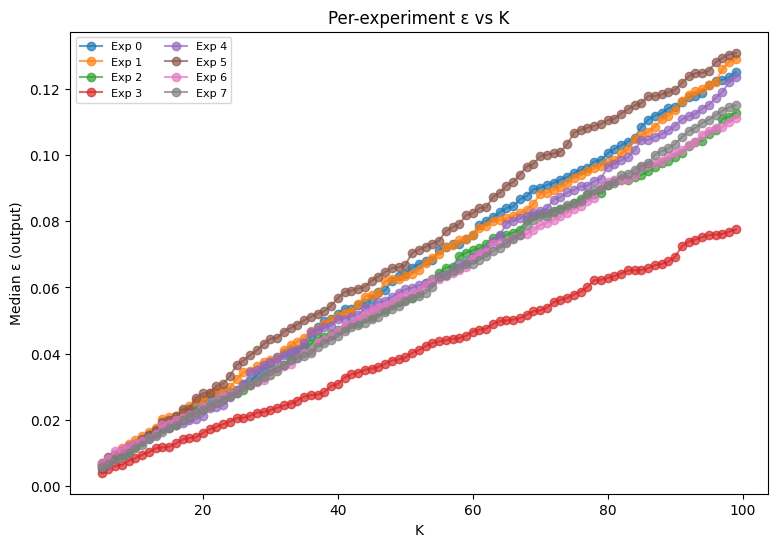

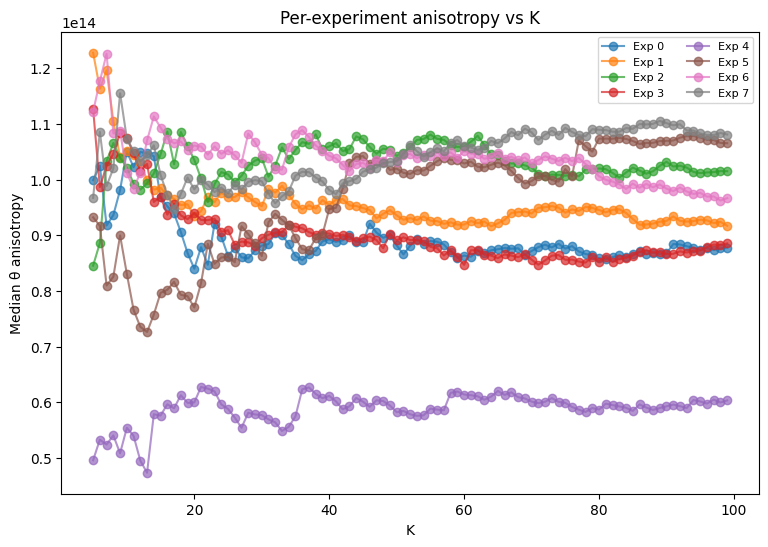

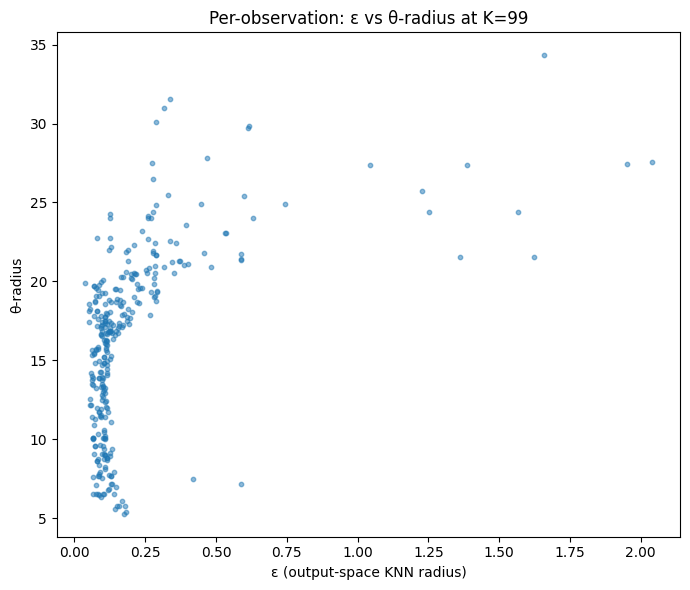

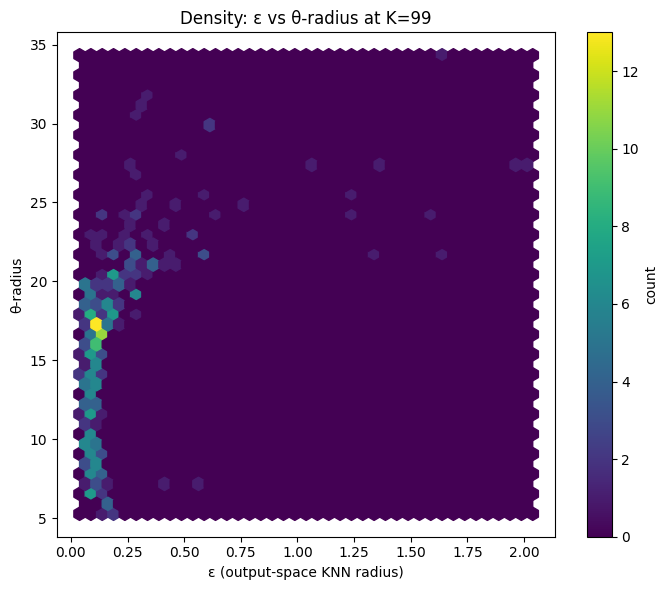

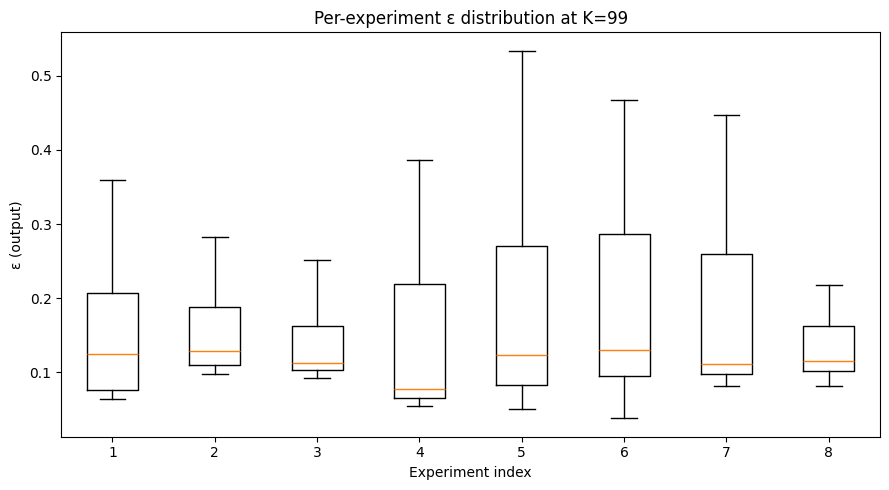

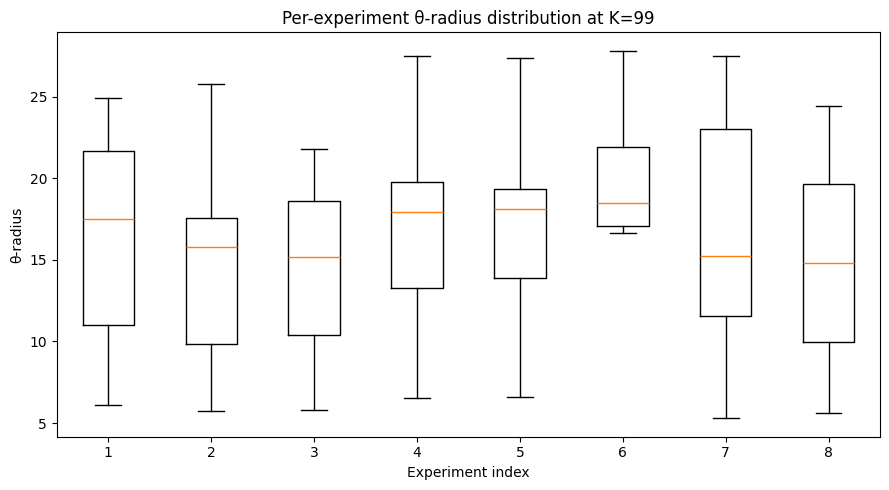

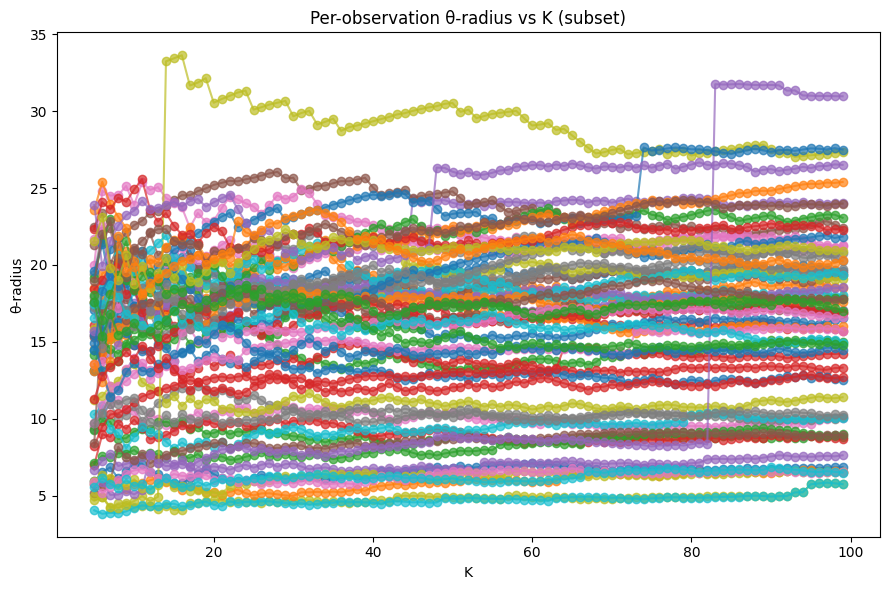

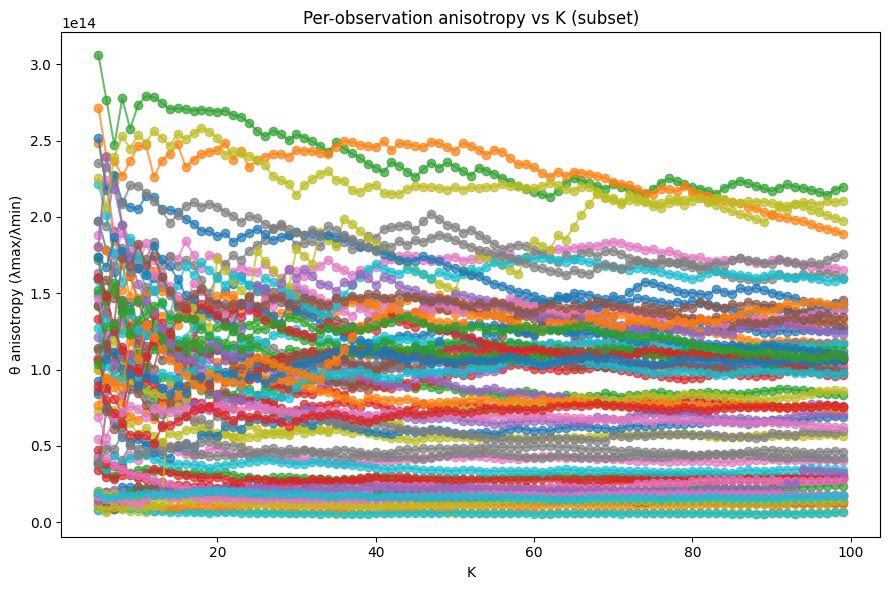

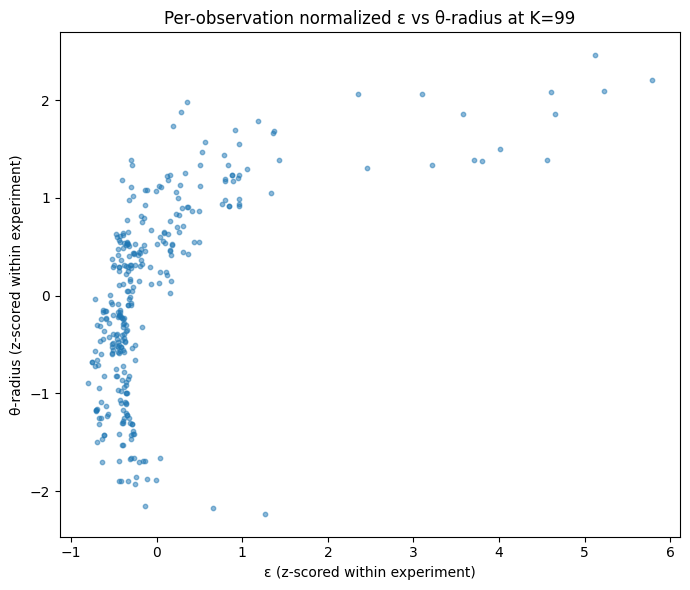

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from src.diagnostics import run_diagnostics_K

run_diagnostics_K(observed_data_list,simulated_data_list,xi_star_list)

In [7]:
import numpy as np
rng = np.random.default_rng(42)

# -------- Multimodal prior over theta (2D) -----------------
def sample_true_uncertainty_model_2d(n, w=0.6):
    """
    Mixture of two Gaussians with different correlations.
    Returns (n, 2).
    """
    n1 = int(np.round(w * n))
    n2 = n - n1
    # Mode A: tight, positively correlated
    mu1 = np.array([1.5, -0.5])
    C1  = np.array([[0.20, 0.15],
                    [0.15, 0.30]])
    th1 = rng.multivariate_normal(mu1, C1, size=n1)
    # Mode B: wider, negatively correlated
    mu2 = np.array([-1.0, 1.2])
    C2  = np.array([[0.60, -0.25],
                    [-0.25, 0.40]])
    th2 = rng.multivariate_normal(mu2, C2, size=n2)
    return np.vstack([th1, th2])



In [8]:
# ------------------ Demo "horse & pony" --------------------
# --- designs (experiments) setup ---
xi_star_list_case2 = [-3.0, -1.0, 0.2, 2.0, 4.0, 8.0, -2.0, 0.1, -6.0, 3.5]  # E = 10
N_emp = 50
N_sim = 50_000

# --- true θ cloud for observations (replicates per experiment) ---
theta_true_cloud = sample_true_uncertainty_model_2d(N_emp)  # (N_emp, 2)

# --- generate observed data per experiment ---
# observations_case2 must be: List[np.ndarray], one array per design e, shape (n_obs_e, d_y)
observations_case2 = []
for xi in xi_star_list_case2:
    y_emp = ridge_switch_model(theta_true_cloud, xi)   # (N_emp, d_y=3)
    observations_case2.append(y_emp)

# --- simulation archive (shared across all experiments) --- # simulation particles
theta_sim = sample_true_uncertainty_model_2d(N_sim)     # (N_sim, 2)  #unknown target

# --- uniform bounds per parameter: [low, high] for θ1 and θ2
THETA_BOUNDS = np.array([[-3.0, 3.0],   # θ1 ∈ [-3, 3]
                         [-3.0, 3.0]])  # θ2 ∈ [-3, 3]

def sample_uniform_theta(n, bounds):
    low  = bounds[:, 0]
    high = bounds[:, 1]
    return np.random.default_rng(0).uniform(low, high, size=(n, bounds.shape[0]))

# global uniform θ used for all experiments


# simulate for ALL experiments and stack
Y_list, Xi_list, Th_list = [], [], []
for xi in xi_star_list_case2:
    theta_sim_uniform = sample_uniform_theta(N_sim, THETA_BOUNDS)    # (N_sim, 2)
    y_sim_e = ridge_switch_model(theta_sim_uniform, xi)                  # (N_sim, 3)
    Y_list.append(y_sim_e)
    Xi_list.append(np.full((N_sim, 1), float(xi)))
    Th_list.append(theta_sim_uniform)                                    # reuse same θ


y_sim = np.vstack(Y_list)        # (E*N_sim, 3)
xi_sim = np.vstack(Xi_list)      # (E*N_sim, 1)
theta_sim_tiled = np.vstack(Th_list)  # (E*N_sim, 2)

# this is what estimate_p_theta_knn_multi expects as 'simulated_data'
simulated_data_case2 = [y_sim, theta_sim_tiled, xi_sim]


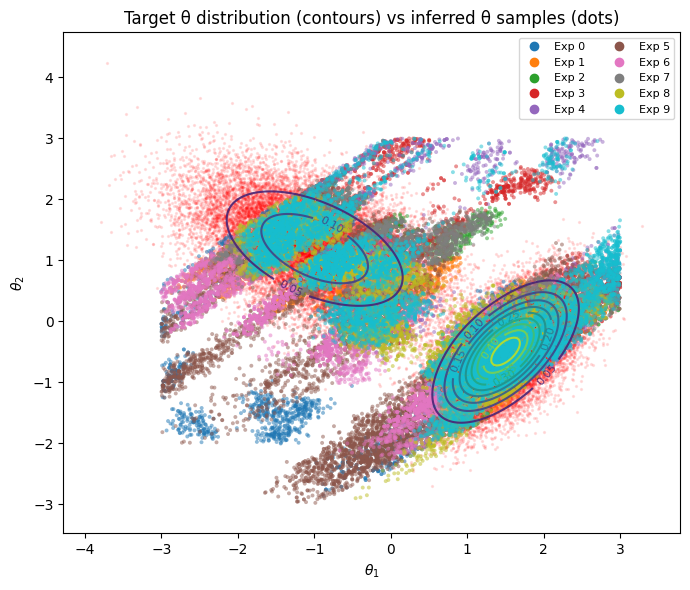

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
res = estimate_p_theta_knn_multi(observations_case2, simulated_data_case2,  xi_star_list_case2 ,
                                 knn=250,  a_tol=0.05, return_full_cov=False, combine_results=True)


# --- 1) get inferred θ samples (flatten, drop NaNs)
Theta_knn = res["combined"]["theta_samples"]            # (sum_nobs, maxK, d_theta)
exp_idx    = res["combined"]["experiment_index"]        # (sum_nobs,)
sum_nobs, maxK, d_theta = Theta_knn.shape
assert d_theta == 2, f"Only 2D plotting supported here (got d_theta={d_theta})."

Theta_knn_flat = Theta_knn.reshape(-1, d_theta)         # (sum_nobs*maxK, 2)
mask = ~np.isnan(Theta_knn_flat).any(axis=1)
Theta_knn_flat = Theta_knn_flat[mask]

# Optional: keep experiment ids aligned with each point (repeat each id maxK times)
exp_idx_rep = np.repeat(exp_idx, maxK)[mask]

# --- 2) get target distribution (archive θ) and fit a GMM as its parametric pdf
# NOTE: simulated_data_case2 = [y_sim, theta_sim_tiled, xi_sim]
theta_archive = theta_sim               # (E*N_sim, 2) tiled across designs
# you can subsample if huge:
# theta_archive = theta_archive[np.random.choice(theta_archive.shape[0], size=10000, replace=False)]

# choose number of components
def fit_gmm_bic(X, max_comp=10):
    best = None
    best_bic = np.inf
    for k in range(1, max_comp+1):
        g = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
        g.fit(X)
        bic = g.bic(X)
        if bic < best_bic:
            best_bic, best = bic, g
    return best

gmm = fit_gmm_bic(theta_archive, max_comp=4)  # or GaussianMixture(2, 'full', 0).fit(theta_archive)

# --- 3) make a grid and evaluate target pdf
all_pts = np.vstack([theta_archive, Theta_knn_flat])
x_min, y_min = all_pts.min(axis=0) - 0.5
x_max, y_max = all_pts.max(axis=0) + 0.5

nx = ny = 250
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                     np.linspace(y_min, y_max, ny))
grid = np.column_stack([xx.ravel(), yy.ravel()])
logpdf = gmm.score_samples(grid)     # log p(θ)
pdf = np.exp(logpdf).reshape(xx.shape)

# --- 4) plot
plt.figure(figsize=(7, 6))
# target distribution contours
cs = plt.contour(xx, yy, pdf, levels=10, alpha=0.9)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

plt.scatter(theta_sim[:,0], theta_sim[:,1], 2, c='r', alpha=0.1)
# inferred θ samples
# color by experiment (optional); otherwise, set c=None and a single color
scatter = plt.scatter(Theta_knn_flat[:,0], Theta_knn_flat[:,1],
                      s=8, alpha=0.5, c=exp_idx_rep, cmap='tab10', edgecolors='none')

plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Target θ distribution (contours) vs inferred θ samples (dots)')

# legend for experiments (optional)
if exp_idx_rep is not None:
    handles, labels = [], []
    for e in np.unique(exp_idx_rep):
        handles.append(plt.Line2D([], [], marker='o', linestyle='',
                                  color=scatter.cmap(scatter.norm(e)), label=f'Exp {e}', markersize=6))
        labels.append(f'Exp {e}')
    plt.legend(handles, labels, frameon=True, fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


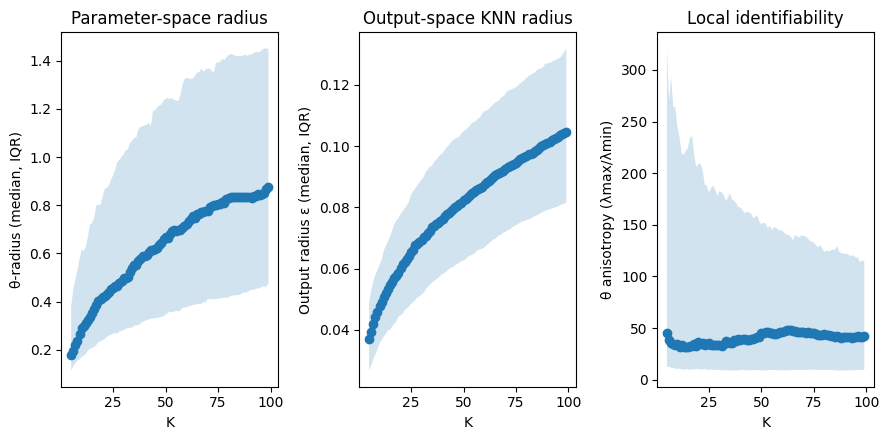

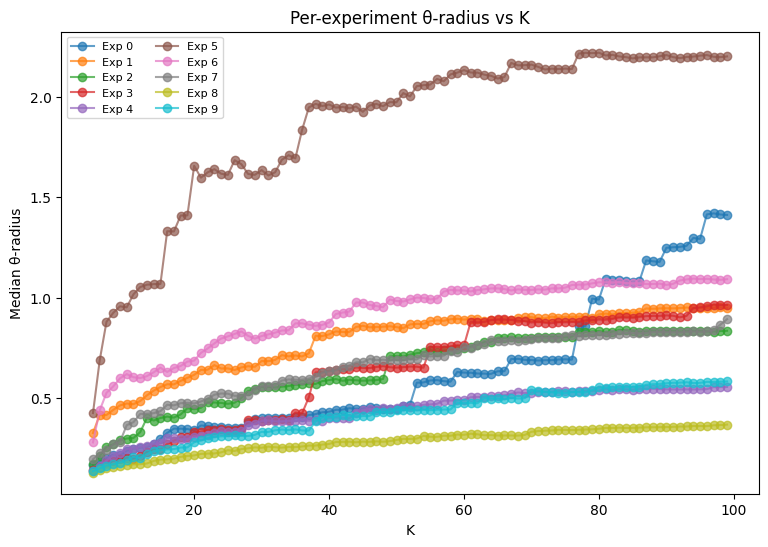

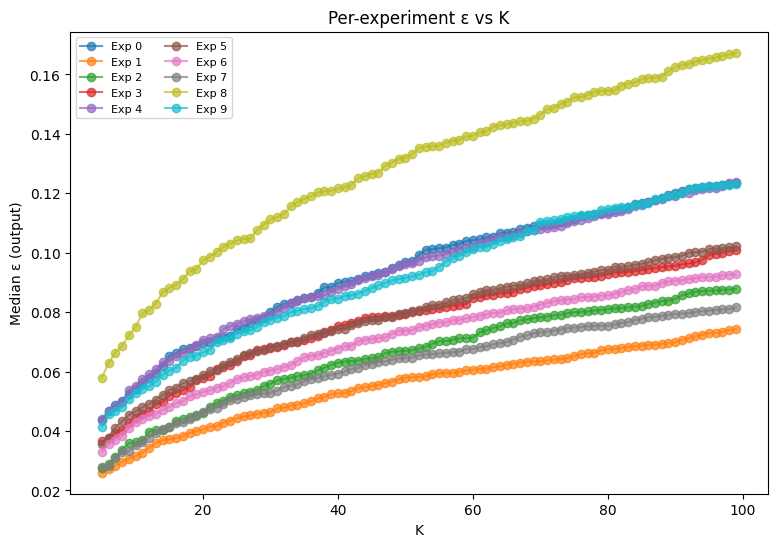

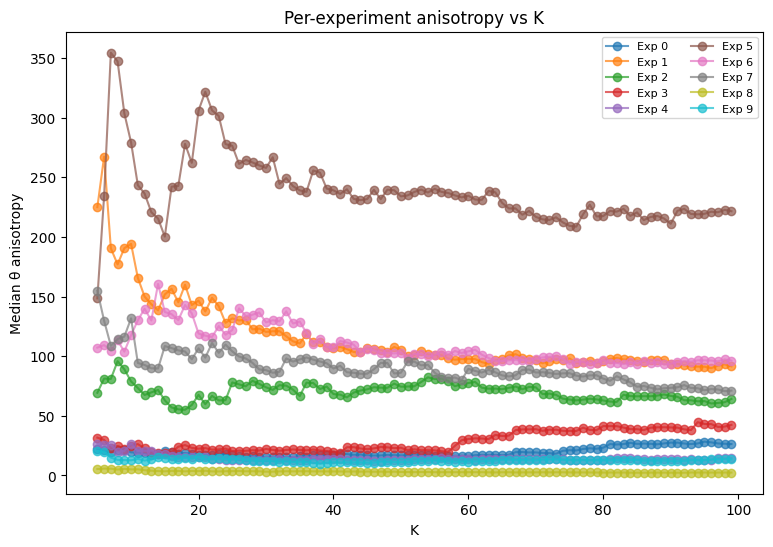

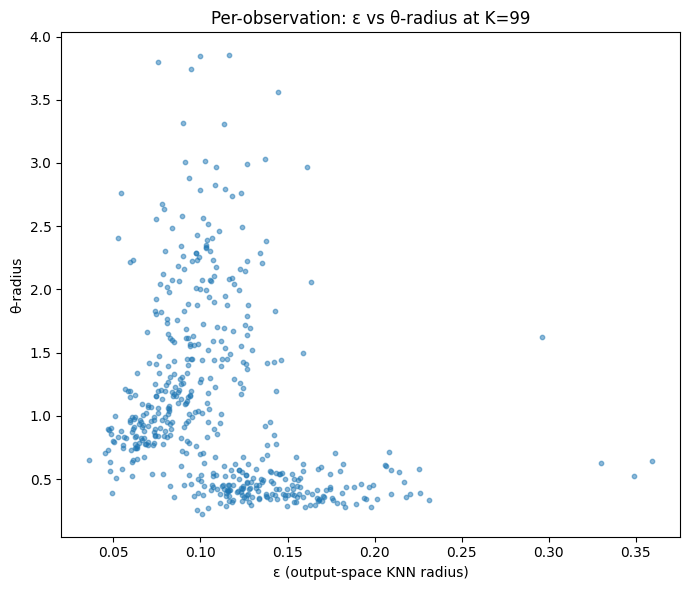

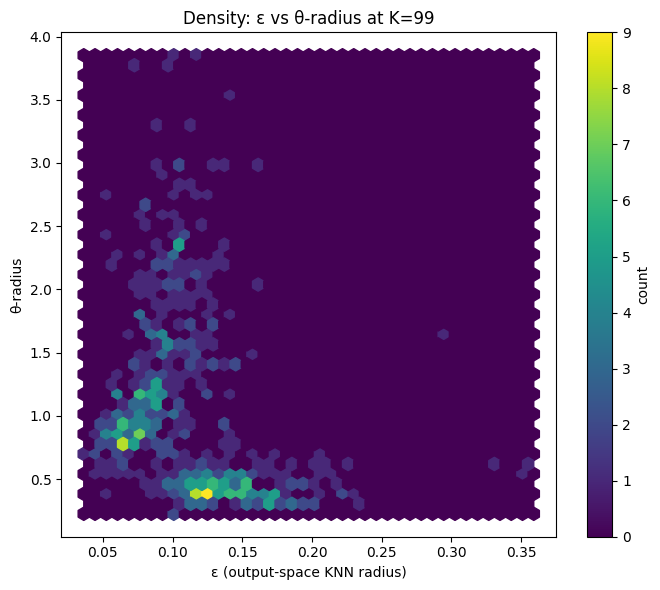

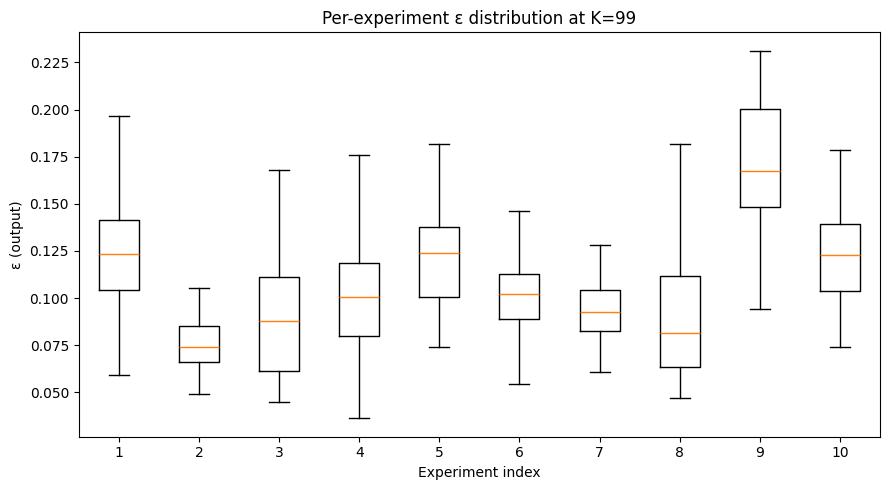

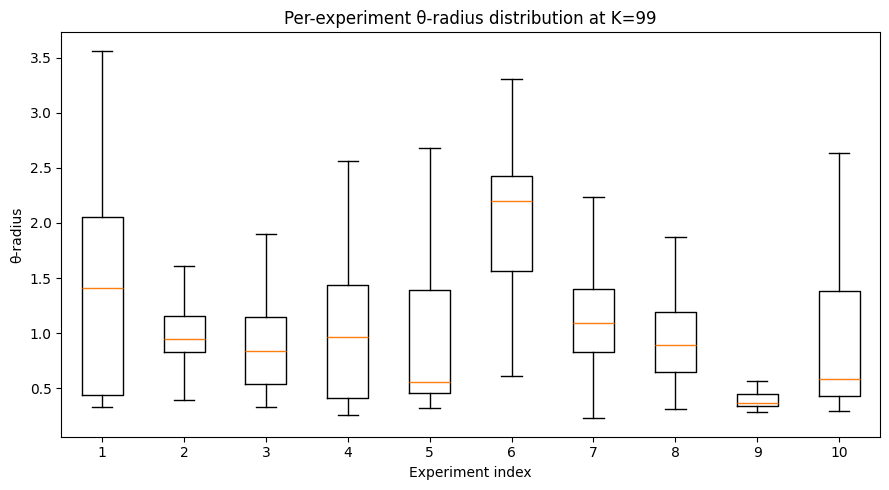

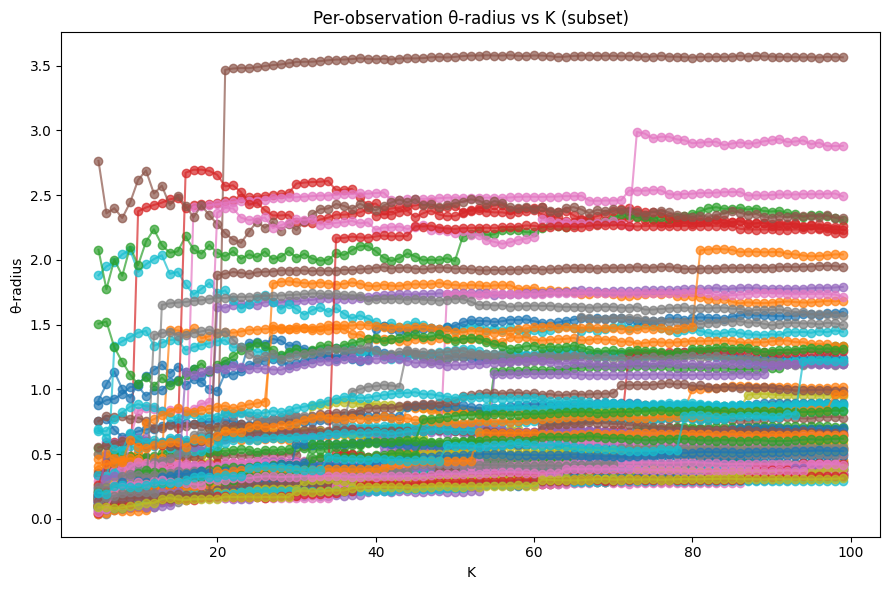

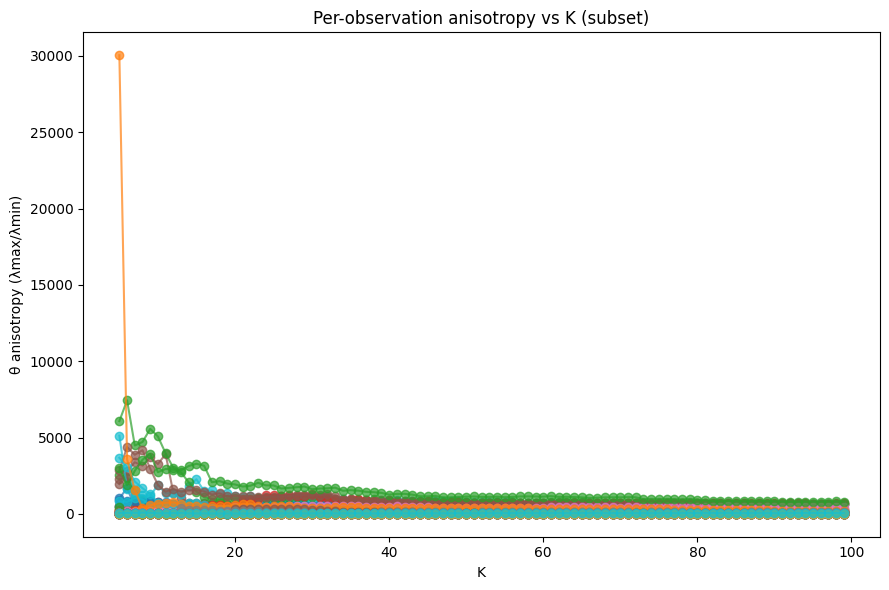

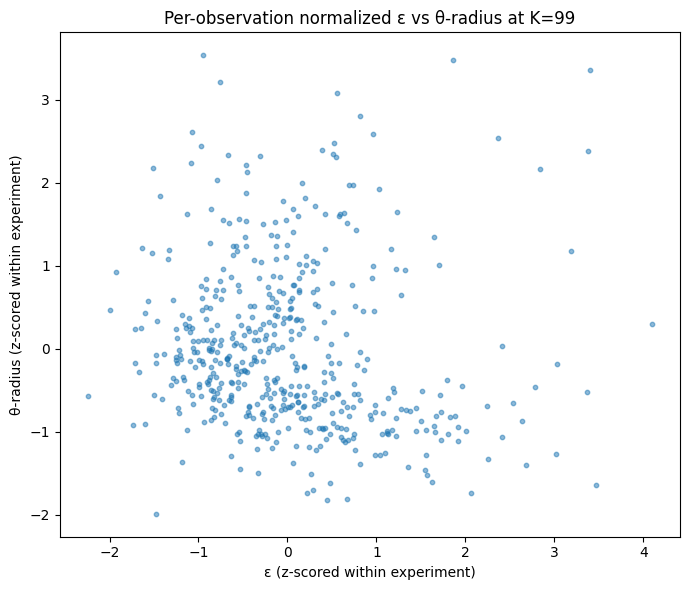

In [10]:
# 3) Call wrapper
run_diagnostics_K(
    observations_case2,          # List of (n_obs_e, d_y)
    simulated_data_case2,        # [y_sim, theta_sim_tiled, xi_sim]
    xi_star_list_case2           # List of designs (length E)
)

In [11]:
from typing import List, Dict, Any, Callable, Optional
import numpy as np
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


def _weighted_cov(X: np.ndarray, w: np.ndarray, ridge: float) -> np.ndarray:
    w = np.asarray(w, dtype=float)
    w = w / max(np.sum(w), 1e-300)
    mu = np.sum(X * w[:, None], axis=0)
    Xc = X - mu
    denom = max(1e-12, 1.0 - np.sum(w ** 2))
    cov = (Xc.T * w) @ Xc / denom
    return cov + ridge * np.eye(X.shape[1])


def _local_kernel_logpdf(
    X_query: np.ndarray,
    Xi: np.ndarray,
    w: np.ndarray,
    cov: np.ndarray,
    inflate: float = 1.0,
) -> np.ndarray:
    X_query = np.atleast_2d(np.asarray(X_query, dtype=float))
    cov_use = inflate * cov
    parts = []
    for wk, muk in zip(w, Xi):
        parts.append(
            np.log(wk + 1e-300)
            + multivariate_normal(mean=muk, cov=cov_use, allow_singular=True).logpdf(X_query)
        )
    return logsumexp(np.column_stack(parts), axis=1)


def estimate_p_theta_knn_multi(
    observed_data_list: List[np.ndarray],
    simulated_data: List[np.ndarray],
    xi_star_list: List[np.ndarray],
    knn: int = 20,
    a_tol: float = 0.05,
    ridge: float = 1e-3,
    combine_results: bool = False,
) -> Dict[str, Any]:
    """
    Multi-experiment KNN inversion with weighted local kernel reconstruction.

    simulated_data can be either:
      [y_sim, theta_sim, xi_sim]
    or
      [y_sim, theta_sim, xi_sim, log_prior, log_prop]
    """
    if len(simulated_data) not in (3, 5):
        raise RuntimeError("simulated_data must contain 3 or 5 arrays.")

    y_sim_all = np.asarray(simulated_data[0], dtype=float)
    theta_sim_all = np.asarray(simulated_data[1], dtype=float)
    xi_sim_all = np.asarray(simulated_data[2], dtype=float)

    log_prior_all = None
    log_prop_all = None
    if len(simulated_data) == 5:
        log_prior_all = np.asarray(simulated_data[3], dtype=float)
        log_prop_all = np.asarray(simulated_data[4], dtype=float)

    if not (y_sim_all.ndim == 2 and theta_sim_all.ndim == 2 and xi_sim_all.ndim == 2):
        raise RuntimeError("simulated_data arrays must be 2D.")

    n_sim0 = y_sim_all.shape[0]
    if theta_sim_all.shape[0] != n_sim0 or xi_sim_all.shape[0] != n_sim0:
        raise RuntimeError("All simulated_data arrays must share the same first dimension.")

    if len(observed_data_list) != len(xi_star_list):
        raise RuntimeError("observed_data_list and xi_star_list must have the same length.")

    sim_valid = (
        ~np.isnan(y_sim_all).any(axis=1)
        & ~np.isnan(theta_sim_all).any(axis=1)
        & ~np.isnan(xi_sim_all).any(axis=1)
    )
    if log_prior_all is not None:
        sim_valid &= ~np.isnan(log_prior_all)
    if log_prop_all is not None:
        sim_valid &= ~np.isnan(log_prop_all)

    valid_idx_global = np.nonzero(sim_valid)[0]
    y_sim = y_sim_all[sim_valid]
    theta_sim = theta_sim_all[sim_valid]
    xi_sim = xi_sim_all[sim_valid]

    if log_prior_all is not None:
        log_prior = log_prior_all[sim_valid]
        log_prop = log_prop_all[sim_valid]
        correction_mode = "importance_corrected"
    else:
        log_prior = np.zeros(y_sim.shape[0], dtype=float)
        log_prop = np.zeros(y_sim.shape[0], dtype=float)
        correction_mode = "neutral"

    per_exp_outputs: List[Dict[str, Any]] = []

    for e, (y_obs_e, xi_star_e) in enumerate(zip(observed_data_list, xi_star_list)):
        y_obs_e = np.asarray(y_obs_e, dtype=float)
        xi_star_e = np.atleast_1d(np.asarray(xi_star_e, dtype=float))

        if y_obs_e.ndim != 2:
            raise RuntimeError(f"observed_data_list[{e}] must be 2D.")
        if y_obs_e.shape[1] != y_sim.shape[1]:
            raise RuntimeError(
                f"Experiment {e}: observed d_y={y_obs_e.shape[1]} vs simulated d_y={y_sim.shape[1]}."
            )
        if xi_star_e.size != xi_sim.shape[1]:
            raise RuntimeError(
                f"Experiment {e}: xi_star dimension {xi_star_e.size} incompatible with d_xi={xi_sim.shape[1]}."
            )

        obs_valid = ~np.isnan(y_obs_e).any(axis=1)
        y_obs_e = y_obs_e[obs_valid]
        if y_obs_e.shape[0] == 0:
            raise ValueError(f"Experiment {e}: no valid observed rows after NaN removal.")

        if np.all(np.abs(xi_star_e) <= 1e-12):
            d_inf = np.max(np.abs(xi_sim - xi_star_e), axis=1)
            mask = d_inf <= a_tol
        else:
            d_inf_rel = np.max(np.abs(xi_sim - xi_star_e) / (np.abs(xi_star_e) + 1e-12), axis=1)
            mask = d_inf_rel <= a_tol

        if not np.any(mask):
            raise ValueError(f"Experiment {e}: no simulations within tolerance of xi_star.")

        y_sim_e = y_sim[mask]
        theta_sim_e = theta_sim[mask]
        log_prior_e = log_prior[mask]
        log_prop_e = log_prop[mask]
        global_idx_e = valid_idx_global[mask]

        scaler = StandardScaler()
        y_sim_e_scaled = scaler.fit_transform(y_sim_e)
        y_obs_e_scaled = scaler.transform(y_obs_e)

        knn_eff = int(min(knn, y_sim_e_scaled.shape[0]))
        nbrs = NearestNeighbors(n_neighbors=knn_eff, algorithm="auto")
        nbrs.fit(y_sim_e_scaled)
        dist_e, knn_idx_e = nbrs.kneighbors(y_obs_e_scaled)

        theta_knn_e = theta_sim_e[knn_idx_e]
        knn_idx_global_e = global_idx_e[knn_idx_e]

        epsilon_e = dist_e[:, -1] + 1e-12
        mean_d_e = dist_e.mean(axis=1)
        std_d_e = dist_e.std(axis=1, ddof=1) if knn_eff > 1 else np.zeros(dist_e.shape[0])

        log_import_e = log_prior_e[knn_idx_e] - log_prop_e[knn_idx_e]
        logw_raw_e = -0.5 * (dist_e / epsilon_e[:, None]) ** 2 + log_import_e
        logw_e = logw_raw_e - logsumexp(logw_raw_e, axis=1, keepdims=True)
        w_e = np.exp(logw_e)

        n_obs_e, _, d_theta = theta_knn_e.shape
        theta_mean_e = np.zeros((n_obs_e, d_theta))
        theta_cov_e = np.zeros((n_obs_e, d_theta, d_theta))
        theta_std_e = np.zeros((n_obs_e, d_theta))
        ess_e = 1.0 / np.maximum(np.sum(w_e ** 2, axis=1), 1e-300)

        for i in range(n_obs_e):
            Xi = theta_knn_e[i]
            wi = w_e[i]
            mu_i = np.sum(Xi * wi[:, None], axis=0)
            cov_i = _weighted_cov(Xi, wi, ridge=ridge)
            theta_mean_e[i] = mu_i
            theta_cov_e[i] = cov_i
            theta_std_e[i] = np.sqrt(np.clip(np.diag(cov_i), 0.0, None))

        theta_centered = theta_knn_e - theta_mean_e[:, None, :]
        theta_pairwise = np.linalg.norm(theta_centered, axis=2)
        theta_radius_e = np.max(theta_pairwise, axis=1)

        eigvals = np.linalg.eigvalsh(theta_cov_e)
        theta_anisotropy_e = eigvals[:, -1] / np.maximum(eigvals[:, 0], 1e-12)

        per_exp_outputs.append({
            "xi_star": xi_star_e.copy(),
            "theta_samples": theta_knn_e,
            "local_weights": w_e,
            "knn_indices": knn_idx_e,
            "knn_indices_global": knn_idx_global_e,
            "epsilon": epsilon_e,
            "output_spread": {
                "distances": dist_e,
                "mean_distance": mean_d_e,
                "std_distance": std_d_e,
            },
            "input_spread": {
                "theta_mean": theta_mean_e,
                "theta_std": theta_std_e,
                "theta_cov": theta_cov_e,
                "theta_radius": theta_radius_e,
                "theta_anisotropy": theta_anisotropy_e,
                "ess": ess_e,
            },
            "meta": {
                "knn_eff": knn_eff,
                "n_sim_filtered": y_sim_e.shape[0],
                "scaler_mean_": scaler.mean_.copy(),
                "scaler_scale_": scaler.scale_.copy(),
            },
        })

    result: Dict[str, Any] = {
        "per_experiment": per_exp_outputs,
        "meta": {
            "n_experiments": len(per_exp_outputs),
            "n_sim_initial": n_sim0,
            "n_sim_after_nan_filter": y_sim.shape[0],
            "correction_mode": correction_mode,
        },
    }

    if combine_results:
        max_knn = max(pe["meta"]["knn_eff"] for pe in per_exp_outputs)
        d_theta = per_exp_outputs[0]["theta_samples"].shape[-1]

        stacked_theta = []
        stacked_weights = []
        stacked_eps = []
        stacked_exp_idx = []

        for e, pe in enumerate(per_exp_outputs):
            th = pe["theta_samples"]
            ww = pe["local_weights"]
            n_obs_e, knn_e, _ = th.shape

            if knn_e < max_knn:
                pad_theta = np.full((n_obs_e, max_knn - knn_e, d_theta), np.nan, dtype=th.dtype)
                pad_w = np.full((n_obs_e, max_knn - knn_e), np.nan, dtype=ww.dtype)
                th = np.concatenate([th, pad_theta], axis=1)
                ww = np.concatenate([ww, pad_w], axis=1)

            stacked_theta.append(th)
            stacked_weights.append(ww)
            stacked_eps.append(pe["epsilon"])
            stacked_exp_idx.append(np.full(n_obs_e, e, dtype=int))

        result["combined"] = {
            "theta_samples": np.concatenate(stacked_theta, axis=0),
            "local_weights": np.concatenate(stacked_weights, axis=0),
            "epsilon": np.concatenate(stacked_eps, axis=0),
            "experiment_index": np.concatenate(stacked_exp_idx, axis=0),
        }

    return result


def evaluate_design_factor_logpdf(
    pe: Dict[str, Any],
    X_query: np.ndarray,
    inflate: float = 1.0,
) -> np.ndarray:
    X_query = np.atleast_2d(np.asarray(X_query, dtype=float))
    local_logs = []
    theta_samples = pe["theta_samples"]
    local_weights = pe["local_weights"]
    theta_cov = pe["input_spread"]["theta_cov"]

    for i in range(theta_samples.shape[0]):
        local_logs.append(
            _local_kernel_logpdf(
                X_query,
                Xi=theta_samples[i],
                w=local_weights[i],
                cov=theta_cov[i],
                inflate=inflate,
            )
        )

    return logsumexp(np.column_stack(local_logs), axis=1) - np.log(theta_samples.shape[0])


def evaluate_posterior_surrogate_logpdf(
    result: Dict[str, Any],
    X_query: np.ndarray,
    prior_logpdf: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    inflate: float = 1.0,
) -> np.ndarray:
    X_query = np.atleast_2d(np.asarray(X_query, dtype=float))
    total = np.zeros(X_query.shape[0], dtype=float)

    if prior_logpdf is not None:
        total += np.asarray(prior_logpdf(X_query), dtype=float)

    for pe in result["per_experiment"]:
        total += evaluate_design_factor_logpdf(pe, X_query, inflate=inflate)

    return total


C:\Users\roberto.rocchetta\AppData\Local\Temp\ipykernel_21972\2085502977.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\roberto.rocchetta\Documents\GitHub\KNNcalibration_experimental\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


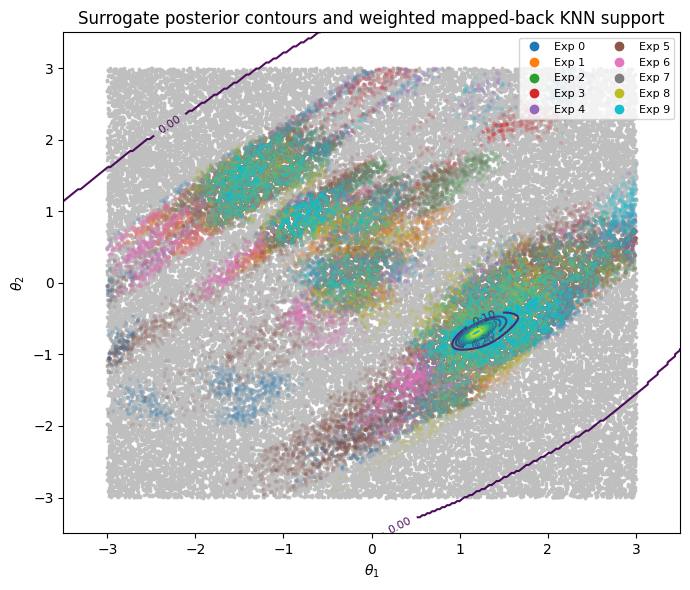

In [12]:
import numpy as np
import matplotlib.pyplot as plt

res = estimate_p_theta_knn_multi(
    observations_case2,
    simulated_data_case2,   # [y_sim, theta_sim, xi_sim] or [y_sim, theta_sim, xi_sim, log_prior, log_prop]
    xi_star_list_case2,
    knn=250,
    a_tol=0.05,
    ridge=1e-3,
    combine_results=True,
)

Theta_knn = res["combined"]["theta_samples"]
W_knn = res["combined"]["local_weights"]
exp_idx = res["combined"]["experiment_index"]

sum_nobs, maxK, d_theta = Theta_knn.shape
assert d_theta == 2, f"Only 2D plotting supported here (got d_theta={d_theta})."

Theta_knn_flat = Theta_knn.reshape(-1, d_theta)
W_knn_flat = W_knn.reshape(-1)
mask = ~np.isnan(Theta_knn_flat).any(axis=1) & ~np.isnan(W_knn_flat)

Theta_knn_flat = Theta_knn_flat[mask]
W_knn_flat = W_knn_flat[mask]
exp_idx_rep = np.repeat(exp_idx, maxK)[mask]

y_sim, theta_sim, xi_sim = simulated_data_case2[:3]
theta_archive = np.asarray(theta_sim, dtype=float)

all_pts = np.vstack([theta_archive, Theta_knn_flat])
x_min, y_min = all_pts.min(axis=0) - 0.5
x_max, y_max = all_pts.max(axis=0) + 0.5

nx = ny = 250
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, nx),
    np.linspace(y_min, y_max, ny),
)
grid = np.column_stack([xx.ravel(), yy.ravel()])

# prior_logpdf = prior_case2.logpdf if hasattr(prior_case2, "logpdf") else None
prior_logpdf = None
logpost = evaluate_posterior_surrogate_logpdf(
    res,
    grid,
    prior_logpdf=prior_logpdf,
    inflate=1.0,
)

pdf = np.exp(logpost - np.max(logpost)).reshape(xx.shape)

plt.figure(figsize=(7, 6))

cs = plt.contour(xx, yy, pdf, levels=10, alpha=0.95)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

plt.scatter(
    theta_archive[:, 0],
    theta_archive[:, 1],
    s=2,
    c="0.75",
    alpha=0.15,
)

scatter = plt.scatter(
    Theta_knn_flat[:, 0],
    Theta_knn_flat[:, 1],
    s=8 + 60 * W_knn_flat,
    c=exp_idx_rep,
    cmap="tab10",
    alpha=np.clip(0.15 + 1.5 * W_knn_flat, 0.15, 0.95),
    edgecolors="none",
)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title(r"Surrogate posterior contours and weighted mapped-back KNN support")

handles, labels = [], []
for e in np.unique(exp_idx_rep):
    handles.append(
        plt.Line2D(
            [], [], marker="o", linestyle="",
            color=scatter.cmap(scatter.norm(e)),
            label=f"Exp {e}", markersize=6
        )
    )
    labels.append(f"Exp {e}")
plt.legend(handles, labels, frameon=True, fontsize=8, ncol=2)

plt.tight_layout()
plt.show()
